Saving picture singapore.jpg to picture singapore.jpg
Image loaded: picture singapore.jpg


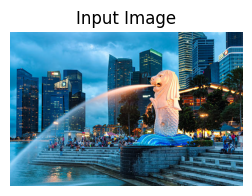

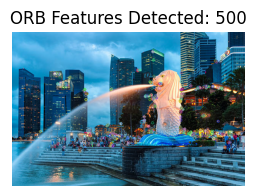

ORB Descriptor Shape:  (500, 32)


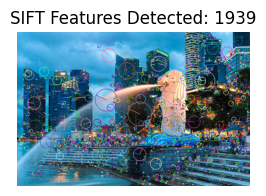

SIFT Descriptor Shape:  (1939, 128)
SURF not available in colab
===== FEATURE EXTRACTION SUMMARY =====
ORB Features : 500
SIFT Features : 1939


In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Image loaded:", image_path)
#read image
img= cv2.imread(image_path)
gray=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#display image
plt.figure(figsize=(3,3))
plt.imshow(gray, cmap='gray')
plt.title("Input Image")
plt.axis("off")
plt.show()
#create ORB detection
orb = cv2.ORB_create(nfeatures=500)
#detect and compute
kp_orb, des_orb = orb.detectAndCompute(gray, None)
#draw keypoints
orb_img = cv2.drawKeypoints(
    gray, kp_orb, None,
    flags=cv2.DrawMatchesFlags_DEFAULT
)
#display image
plt.figure(figsize=(3,3))
plt.imshow(orb_img, cmap='gray')
plt.title(f"ORB Features Detected: {len(kp_orb)}")
plt.axis("off")
plt.show()

print("ORB Descriptor Shape: ", des_orb.shape)

#create SIFT detector
sift = cv2.SIFT_create()
#detect and compute
kp_sift, des_sift = sift.detectAndCompute(gray, None)

#draw keypoints
sift_img = cv2.drawKeypoints(
    gray, kp_sift, None,
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

#display
plt.figure(figsize=(3,3))
plt.imshow(sift_img, cmap='gray')
plt.title(f"SIFT Features Detected: {len(kp_sift)}")
plt.axis("off")
plt.show()

print("SIFT Descriptor Shape: ", des_sift.shape)

#SURF IS PATENTED AND USUALLY UNavailable in colab
try:
  surf = cv2.xfeatures2d.SURF_create(400)
  kp_surf, des_surf = surf.detectAndCompute(gray, None)

  surf_img = cv2.drawKeypoints(
      gray, kp_surf, None,
      flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
  )

  plt.figure(figsize=(3,3))
  plt.imshow(surf_img, cmap='gray')
  plt.title(f"SURF Features Detected: {len(kp_surf)}")
  plt.axis("off")
  plt.show()

  print("SURF Descriptor Shape: ", des_surf.shape)
except:
  print("SURF not available in colab")

  print("===== FEATURE EXTRACTION SUMMARY =====")
  print("ORB Features :", len(kp_orb))
  print("SIFT Features :", len(kp_sift))